1: Импорт библиотек (Code)

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube

# Настройка устройства (GPU, если доступно, иначе CPU или MPS для Mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Используемое устройство: {device}")

# Зафиксируем сиды для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Используемое устройство: cpu


In [5]:
# --- Физические параметры ---
# --- Физические параметры ---
alpha = 0.05 # Коэффициент температуропроводности
T_max = 1.0 # Конечное время симуляции
L = 1.0 # Размер пластины (1x1)
# Температурные условия
# Количество точек
N_ic = 2000 # Точки для начального условия (t = 0)
N_bc = 4000 # Точки для граничных условий (края пластины)
N_col = 15000 # Точки коллокации внутри домена (для физики)

# Конвертируем всё в тензоры PyTorch и переносим на устройство (GPU/CPU)
def to_tensor(arr, requires_grad=False):
 tensor = torch.tensor(arr, dtype=torch.float32).to(device)
 tensor.requires_grad = requires_grad
 return tensor
# Температурные условия
T_0 = 20.0      # Начальная температура всей пластины и холодных краев
# Вместо фиксированного T_hot на границе, все края теперь холодные
T_ambient = 20.0 
    
# --- 1. Генерация точек коллокации (Physics) ---
sampler = LatinHypercube(d=3)
sample_points = sampler.random(n=N_col)

x_col = sample_points[:, 0:1] * L
y_col = sample_points[:, 1:2] * L
t_col = sample_points[:, 2:3] * T_max

x_col_t = to_tensor(x_col, requires_grad=True)
y_col_t = to_tensor(y_col, requires_grad=True)
t_col_t = to_tensor(t_col, requires_grad=True)

# --- 2. Начальные условия (IC) ---
x_ic = np.random.uniform(0, L, (N_ic, 1))
y_ic = np.random.uniform(0, L, (N_ic, 1))
t_ic = np.zeros((N_ic, 1))
u_ic = np.full((N_ic, 1), T_0)

x_ic_t, y_ic_t, t_ic_t, u_ic_t = to_tensor(x_ic), to_tensor(y_ic), to_tensor(t_ic), to_tensor(u_ic)

# --- 3. Граничные условия (BC) - все стороны холодные ---
N_edge = N_bc // 4
t_bc_all = np.random.uniform(0, T_max, (N_bc, 1))
pts = np.random.uniform(0, L, (N_bc, 1))

x_bc = np.zeros((N_bc, 1))
y_bc = np.zeros((N_bc, 1))
u_bc = np.full((N_bc, 1), T_0) 

# Заполнение сторон
# Bottom (y=0)
x_bc[0:N_edge] = pts[0:N_edge]; y_bc[0:N_edge] = 0.0
# Top (y=L)
x_bc[N_edge:2*N_edge] = pts[N_edge:2*N_edge]; y_bc[N_edge:2*N_edge] = L
# Left (x=0)
x_bc[2*N_edge:3*N_edge] = 0.0; y_bc[2*N_edge:3*N_edge] = pts[2*N_edge:3*N_edge]
# Right (x=L)
x_bc[3*N_edge:] = L; y_bc[3*N_edge:] = pts[3*N_edge:]

x_bc_t = to_tensor(x_bc)
y_bc_t = to_tensor(y_bc)
t_bc_t = to_tensor(t_bc_all)
u_bc_t = to_tensor(u_bc)

print(f"Данные созданы. BC точки: {len(x_bc)} (по {N_edge} на каждую из 4-х сторон)")

Данные созданы. BC точки: 4000 (по 1000 на каждую из 4-х сторон)


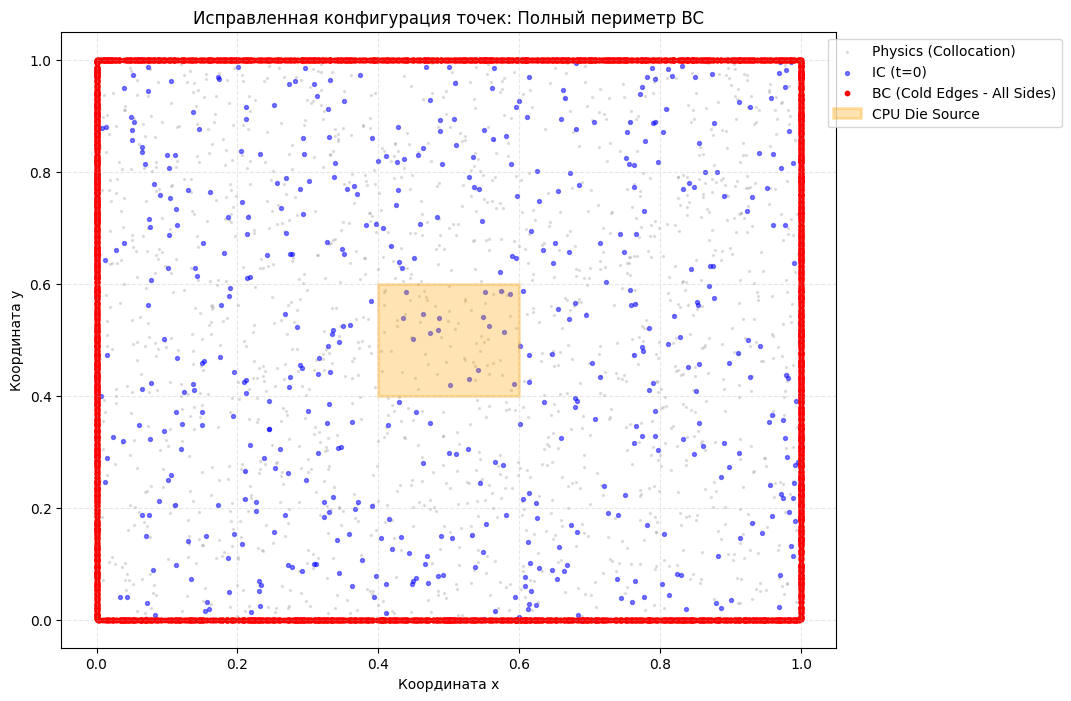

In [6]:
import matplotlib.patches as patches

plt.figure(figsize=(10, 8))

# Точки внутри (Physics)
plt.scatter(x_col[:1500], y_col[:1500], c='gray', s=2, alpha=0.2, label='Physics (Collocation)')

# Начальное состояние (t=0)
plt.scatter(x_ic[:500], y_ic[:500], c='blue', s=8, alpha=0.5, label='IC (t=0)')

# ГРАНИЦЫ (BC) - теперь рисуем все точки
plt.scatter(x_bc, y_bc, c='red', s=10, label='BC (Cold Edges - All Sides)')

# Область процессора
ax = plt.gca()
chip_rect = patches.Rectangle((0.4, 0.4), 0.2, 0.2, linewidth=2, 
                              edgecolor='orange', facecolor='orange', 
                              alpha=0.3, label='CPU Die Source')
ax.add_patch(chip_rect)

plt.title("Исправленная конфигурация точек: Полный периметр BC")
plt.xlabel("Координата x")
plt.ylabel("Координата y")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [7]:
class PINN(nn.Module):
    def __init__(self, num_hidden_layers=5, num_neurons=60):
        super(PINN, self).__init__()
        
        layers =[]
        # Входной слой: (x, y, t) -> 3 нейрона
        layers.append(nn.Linear(3, num_neurons))
        layers.append(nn.Tanh())
        
        # Скрытые слои
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.Tanh())
            
        # Выходной слой: 1 нейрон (температура u)
        layers.append(nn.Linear(num_neurons, 1))
        
        self.net = nn.Sequential(*layers)
        
    def forward(self, x, y, t):
        # Объединяем тензоры в один вектор [N, 3]
        inputs = torch.cat([x, y, t], dim=1)
        return self.net(inputs)

model = PINN().to(device)
print(model)

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=60, bias=True)
    (1): Tanh()
    (2): Linear(in_features=60, out_features=60, bias=True)
    (3): Tanh()
    (4): Linear(in_features=60, out_features=60, bias=True)
    (5): Tanh()
    (6): Linear(in_features=60, out_features=60, bias=True)
    (7): Tanh()
    (8): Linear(in_features=60, out_features=60, bias=True)
    (9): Tanh()
    (10): Linear(in_features=60, out_features=60, bias=True)
    (11): Tanh()
    (12): Linear(in_features=60, out_features=1, bias=True)
  )
)


In [8]:
def get_source_term(x, y, t):
    intensity = 500.0 
    sigma = 0.1 
    # Центр чипа в (0.5, 0.5)
    chip_area = torch.exp(-((x - 0.5)**2 + (y - 0.5)**2) / (2 * sigma**2))
    return intensity * chip_area

In [15]:
mse_loss = nn.MSELoss()
def calculate_loss(model):
    # 1. IC Loss
    u_ic_pred = model(x_ic_t, y_ic_t, t_ic_t)
    loss_ic = mse_loss(u_ic_pred, torch.zeros_like(u_ic_pred)) # T_0 -> 0.0
    
    # 2. BC: теперь цель 0.0
    u_bc_pred = model(x_bc_t, y_bc_t, t_bc_t)
    loss_bc = mse_loss(u_bc_pred, torch.zeros_like(u_bc_pred)) # T_ambient -> 0.0
    
    # 3. PDE Loss
    u_pred = model(x_col_t, y_col_t, t_col_t)
    
    u_t = torch.autograd.grad(u_pred, t_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_x = torch.autograd.grad(u_pred, x_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_y = torch.autograd.grad(u_pred, y_col_t, grad_outputs=torch.ones_like(u_pred), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_col_t, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_col_t, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    
    Q = get_source_term(x_col_t, y_col_t, t_col_t) / 100.0 
    
    f_pred = u_t - alpha * (u_xx + u_yy) - Q
    loss_pde = mse_loss(f_pred, torch.zeros_like(f_pred))
    
    # ВЕСА: Сначала даем PDE огромный вес, чтобы сеть вообще заметила, что есть нагрев
    # Это "разбудит" модель
    total_loss = 1.0 * loss_ic + 1.0 * loss_bc + 10.0 * loss_pde
    
    return total_loss, loss_ic, loss_bc, loss_pde

=== Запуск оптимизатора Adam ===
Epoch    0 | Total Loss: 8.0781e+02 | IC: 4.0000e+02 | BC: 4.0000e+02 | PDE: 7.8045e-01
Epoch  500 | Total Loss: 6.4392e+00 | IC: 1.0631e-02 | BC: 1.6656e-02 | PDE: 6.4119e-01
Epoch 1000 | Total Loss: 7.6162e-02 | IC: 2.8806e-02 | BC: 5.6819e-03 | PDE: 4.1674e-03
Epoch 1500 | Total Loss: 3.7558e-02 | IC: 1.8096e-02 | BC: 2.4305e-03 | PDE: 1.7031e-03
Epoch 2000 | Total Loss: 2.7615e-02 | IC: 1.4109e-02 | BC: 1.5378e-03 | PDE: 1.1968e-03
Epoch 2500 | Total Loss: 2.4485e-02 | IC: 1.2733e-02 | BC: 1.3568e-03 | PDE: 1.0396e-03

=== Запуск оптимизатора L-BFGS ===
Обучение завершено! Final Loss: 2.0007e-03 (PDE: 9.4342e-05)


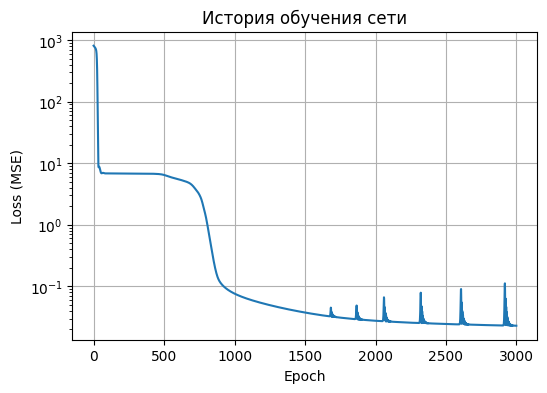

In [16]:
# Оптимизатор 1: Adam
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs_adam = 3000
loss_history =[]

print("=== Запуск оптимизатора Adam ===")
for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    loss, l_ic, l_bc, l_pde = calculate_loss(model)
    loss.backward()
    optimizer_adam.step()
    
    loss_history.append(loss.item())
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {loss.item():.4e} | IC: {l_ic.item():.4e} | BC: {l_bc.item():.4e} | PDE: {l_pde.item():.4e}")

# Оптимизатор 2: L-BFGS (очень хорош для гладких физических задач)
print("\n=== Запуск оптимизатора L-BFGS ===")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    lr=1.0, 
    max_iter=2000, 
    tolerance_grad=1e-7, 
    tolerance_change=1e-9, 
    history_size=50
)

# Для L-BFGS нужна функция-замыкание (closure)
def closure():
    optimizer_lbfgs.zero_grad()
    loss, _, _, _ = calculate_loss(model)
    loss.backward()
    return loss

optimizer_lbfgs.step(closure)

# Финальный лосс
final_loss, f_ic, f_bc, f_pde = calculate_loss(model)
print(f"Обучение завершено! Final Loss: {final_loss.item():.4e} (PDE: {f_pde.item():.4e})")

# Построим график падения функции потерь (для Adam)
plt.figure(figsize=(6, 4))
plt.plot(loss_history, label='Total Loss (Adam)')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('История обучения сети')
plt.grid(True)
plt.show()

In [11]:
def solve_fdm(nx=50, ny=50, nt=500):
    """Классическое решение методом конечных разностей"""
    dx = L / (nx - 1); dy = L / (ny - 1); dt = T_max / nt
    u = np.full((ny, nx), T_ambient)
    
    # Итерационный цикл по времени
    for n in range(nt):
        un = u.copy()
        # Вычисляем источник для всей сетки
        x_m, y_m = np.meshgrid(np.linspace(0, L, nx), np.linspace(0, L, ny))
        # Аналог функции источника на numpy
        Q_fdm = 300.0 * np.exp(-((x_m - 0.5)**2 + (y_m - 0.5)**2) / (2 * 0.1**2))
        
        # Схема "явная по времени"
        u[1:-1, 1:-1] = (un[1:-1, 1:-1] +
                         alpha * dt / dx**2 * (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2]) +
                         alpha * dt / dy**2 * (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1]) +
                         dt * Q_fdm[1:-1, 1:-1])
        # Граничные условия Дирихле (холодные края)
        u[0,:] = u[-1,:] = u[:,0] = u[:,-1] = T_ambient
        
    return u # Возвращает финальное состояние

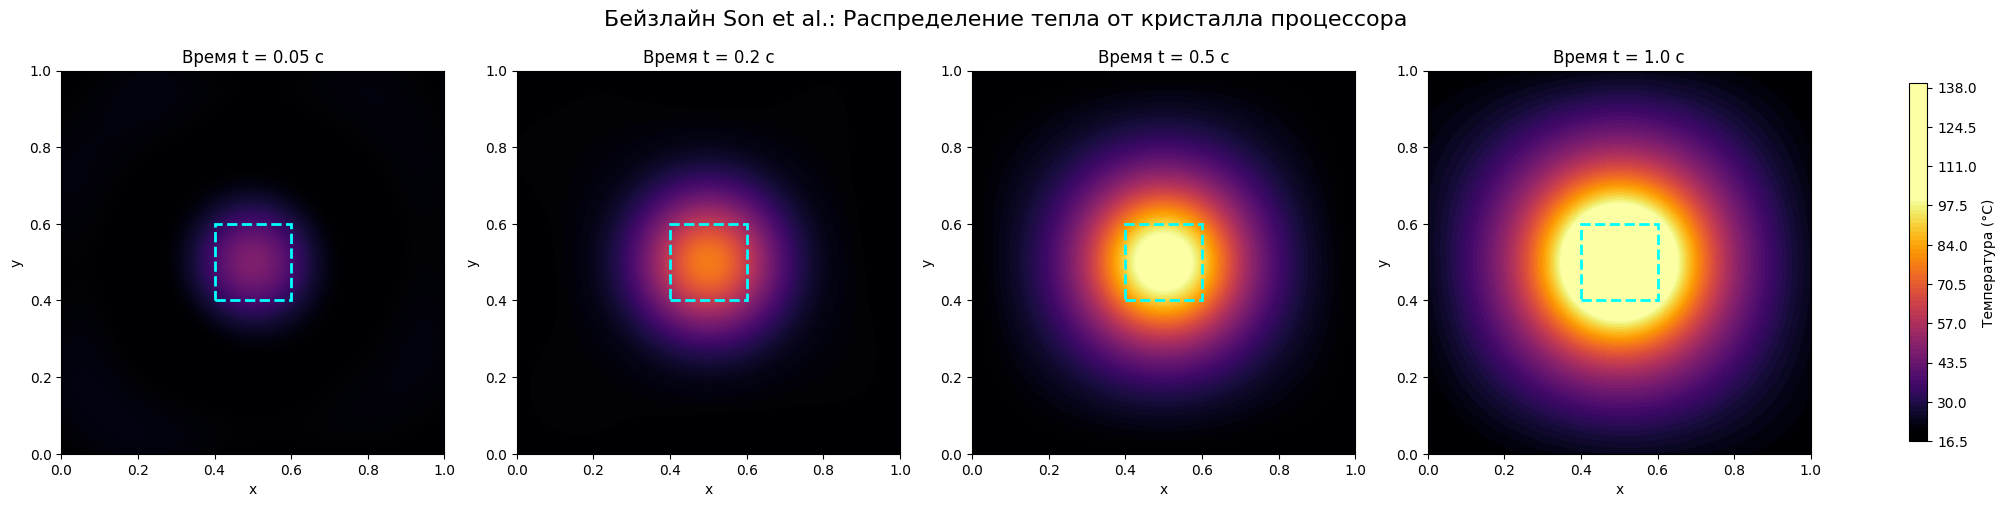

In [17]:

# Улучшенная визуализация для микропроцессорной модели
time_steps = [0.05, 0.2, 0.5, 1.0] # Моменты времени
fig, axes = plt.subplots(1, len(time_steps), figsize=(20, 5), constrained_layout=True)

for ax, t_val in zip(axes, time_steps):
    T_flat = np.full_like(X_flat, t_val)
    X_t = torch.tensor(X_flat, dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y_flat, dtype=torch.float32, device=device)
    T_t = torch.tensor(T_flat, dtype=torch.float32, device=device)

    # --- В ячейке визуализации (измени расчет U_pred) ---
    with torch.no_grad():
        # 1. Получаем предсказание нейросети
        U_norm = model(X_t, Y_t, T_t).cpu().numpy().reshape(ny, nx)
        
        # 2. Обратная трансформация (Де-нормализация)
        # Мы учили сеть, что границы (20) - это 0, а масштаб источника был ~100
        U_final = U_norm * 100.0 + 20.0 

    # Теперь рисуй тепловую карту для U_final
    cf = ax.contourf(X_mesh, Y_mesh, U_final, levels=100, cmap="inferno", vmin=20, vmax=100)
    
    # Рисуем контур "чипа" в центре для наглядности
    chip_rect = patches.Rectangle((0.4, 0.4), 0.2, 0.2, linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--', label='CPU Die')
    ax.add_patch(chip_rect)
    
    ax.set_title(f"Время t = {t_val} c")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

# Общий colorbar
cbar = fig.colorbar(cf, ax=axes, shrink=0.8)
cbar.set_label("Температура (°C)")
fig.suptitle("Бейзлайн Son et al.: Распределение тепла от кристалла процессора", fontsize=16)
plt.show()


=== Запуск новой секции: 2D Laplace PINN + FDM article сравнение ===
PINNLaplace(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): Tanh()
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
=== Тренировка PINN для Лапласа (Adam) ===
Epoch    0 | Loss=4.1408e+02 | BC=4.1408e-01 | PDE=6.3217e-05
Epoch 1000 | Loss=2.1296e+00 | BC=9.2816e-04 | PDE=1.2015e+00
Epoch 2000 | Loss=4.5351e-01 | BC=1.4807e-04 | PDE=3.0544e-01
Epoch 3000 | Loss=2.8593e-01 | BC=1.2710e-04 | PDE=1.5883e-01
Epoch 4000 | Loss=8.0563e-02 | BC=3.4587e-05 | PDE=4.5976e-02
=== L-BFGS оптимизац

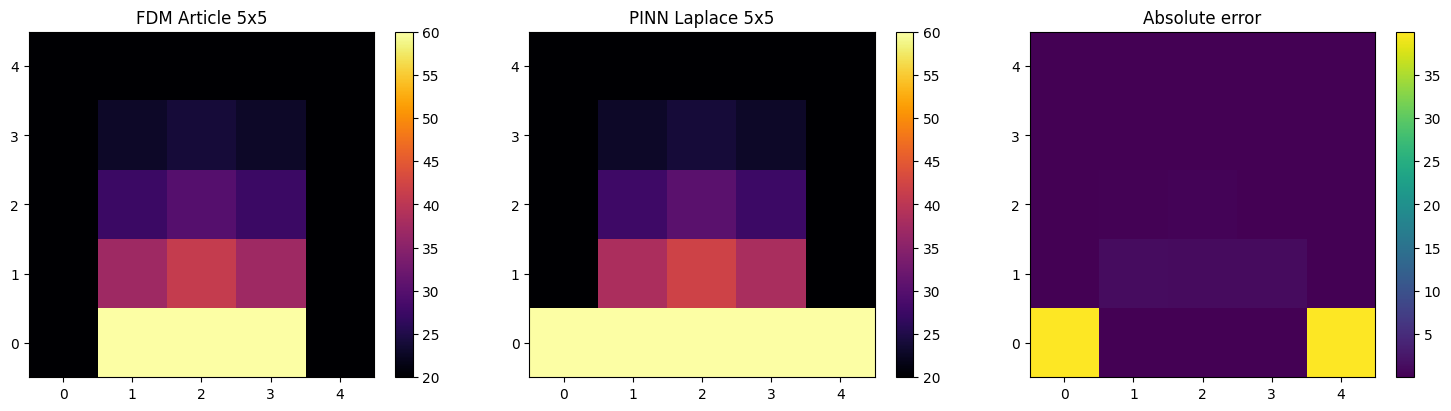

In [4]:
# --- 2D Laplace PINN + сравнение с FDM из статьи (5x5) ---
print("\n=== Запуск новой секции: 2D Laplace PINN + FDM article сравнение ===")

# Параметры сетки
nx, ny = 5, 5
L = 1.0
T_cold = 20.0
T_hot = 60.0

x_lin = np.linspace(0, L, nx)
y_lin = np.linspace(0, L, ny)
X_mesh, Y_mesh = np.meshgrid(x_lin, y_lin)

bc_points = []
bc_temps = []
for j in range(ny):
    for i in range(nx):
        x_val = X_mesh[j, i]
        y_val = Y_mesh[j, i]
        if i == 0 or i == nx - 1 or j == 0 or j == ny - 1:
            bc_points.append([x_val, y_val])
            if j == 0:
                bc_temps.append([T_hot])
            else:
                bc_temps.append([T_cold])

bc_points = np.array(bc_points)
bc_temps = np.array(bc_temps)

x_bc = torch.tensor(bc_points[:, 0:1], dtype=torch.float32, requires_grad=True).to(device)
y_bc = torch.tensor(bc_points[:, 1:2], dtype=torch.float32, requires_grad=True).to(device)
T_bc_true = torch.tensor(bc_temps, dtype=torch.float32).to(device)

# Нормализация температур: 20°C -> 0, 60°C -> 1
T_bc_true_normalized = (T_bc_true - 20.0) / 40.0

N_col = 5000
sampler2 = LatinHypercube(d=2)
sample_points = sampler2.random(n=N_col)
x_col = torch.tensor((sample_points[:, 0:1] * L), dtype=torch.float32, requires_grad=True).to(device)
y_col = torch.tensor((sample_points[:, 1:2] * L), dtype=torch.float32, requires_grad=True).to(device)

class PINNLaplace(nn.Module):
    def __init__(self, num_hidden_layers=5, num_neurons=64):
        super().__init__()
        layers = []
        layers.append(nn.Linear(2, num_neurons))
        layers.append(nn.Tanh())
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(num_neurons, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

model_laplace = PINNLaplace().to(device)
print(model_laplace)

mse_loss = nn.MSELoss()

def calculate_loss_laplace():
    T_bc_pred = model_laplace(x_bc, y_bc)
    loss_bc = mse_loss(T_bc_pred, T_bc_true_normalized)

    T_pred = model_laplace(x_col, y_col)
    T_x = torch.autograd.grad(T_pred, x_col, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]
    T_y = torch.autograd.grad(T_pred, y_col, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]
    T_xx = torch.autograd.grad(T_x, x_col, grad_outputs=torch.ones_like(T_x), create_graph=True)[0]
    T_yy = torch.autograd.grad(T_y, y_col, grad_outputs=torch.ones_like(T_y), create_graph=True)[0]

    f_pred = T_xx + T_yy
    loss_pde = mse_loss(f_pred, torch.zeros_like(f_pred))

    total_loss = 1000.0 * loss_bc + 1.0 * loss_pde
    return total_loss, loss_bc, loss_pde

optimizer_adam = torch.optim.Adam(model_laplace.parameters(), lr=1e-3)
epochs_adam = 5000

print("=== Тренировка PINN для Лапласа (Adam) ===")
for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    loss_val, l_bc, l_pde = calculate_loss_laplace()
    loss_val.backward()
    optimizer_adam.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:4d} | Loss={loss_val.item():.4e} | BC={l_bc.item():.4e} | PDE={l_pde.item():.4e}")

print("=== L-BFGS оптимизация ===")
optimizer_lbfgs = torch.optim.LBFGS(model_laplace.parameters(), lr=1.0, max_iter=2000, tolerance_grad=1e-7, tolerance_change=1e-9, history_size=50)

def closure_laplace():
    optimizer_lbfgs.zero_grad()
    loss_val, _, _ = calculate_loss_laplace()
    loss_val.backward()
    return loss_val

optimizer_lbfgs.step(closure_laplace)

loss_final, l_bc_final, l_pde_final = calculate_loss_laplace()
print(f"Обучение завершено: Total={loss_final.item():.4e} BC={l_bc_final.item():.4e} PDE={l_pde_final.item():.4e}")

X_flat = X_mesh.ravel()[:, None]
Y_flat = Y_mesh.ravel()[:, None]

x_eval = torch.tensor(X_flat, dtype=torch.float32).to(device)
y_eval = torch.tensor(Y_flat, dtype=torch.float32).to(device)
with torch.no_grad():
    T_pinn_normalized = model_laplace(x_eval, y_eval).cpu().numpy().reshape(ny, nx)
    T_pinn_flat = T_pinn_normalized * 40.0 + 20.0




FDM сошлось за 25 итераций
=== Сравнение PINN vs FDM ===
T13 FDM   = 30.000000 °C
T13 PINN  = 30.406380 °C
Diff      = 0.406380 °C


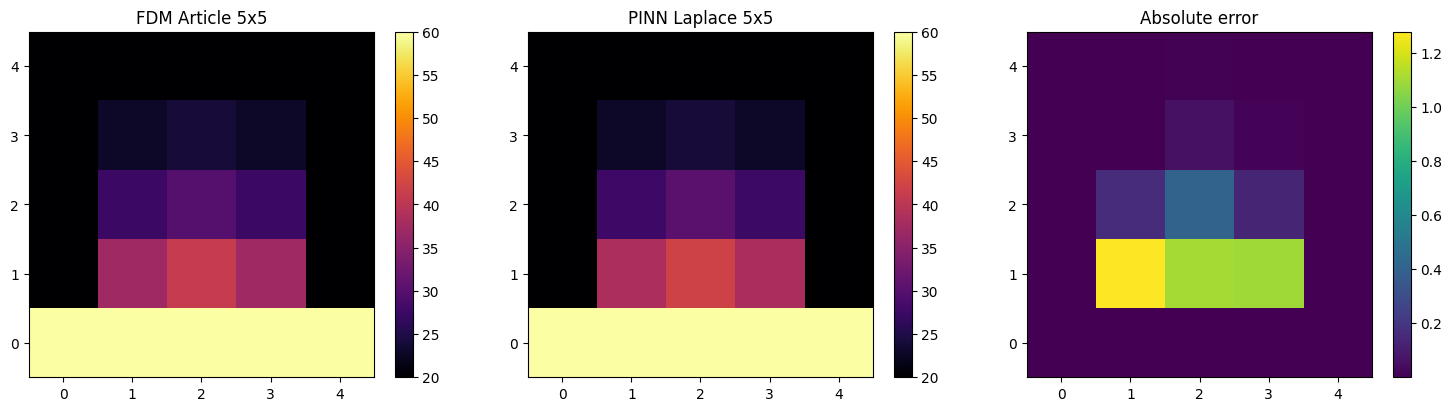

In [6]:
def solve_fdm_article(nx=5, ny=5, max_iter=10000, tol=1e-6, lambda_sor=1.5):
    T = np.full((ny, nx), T_cold, dtype=np.float64)
        # Вариант "Горячий низ в приоритете"
    T[:, 0] = T_cold   # Сначала холодные бока
    T[:, -1] = T_cold
    T[-1, :] = T_cold  # Холодный верх
    T[0, :] = T_hot    # В последнюю очередь горячий низ (он перезапишет углы в 60°C)

    for it in range(max_iter):
        max_diff = 0.0
        T_old = T.copy()
        for j in range(1, ny - 1):
            for i in range(1, nx - 1):
                T_new = 0.25 * (T[j + 1, i] + T[j - 1, i] + T[j, i + 1] + T[j, i - 1])
                T[j, i] = lambda_sor * T_new + (1.0 - lambda_sor) * T[j, i]
                diff = abs(T[j, i] - T_old[j, i])
                if diff > max_diff:
                    max_diff = diff
        if max_diff < tol:
            print(f"FDM сошлось за {it} итераций")
            break
    return T

T_fdm = solve_fdm_article()

print("=== Сравнение PINN vs FDM ===")
print(f"T13 FDM   = {T_fdm[2, 2]:.6f} °C")
print(f"T13 PINN  = {T_pinn_flat[2, 2]:.6f} °C")
print(f"Diff      = {abs(T_fdm[2, 2] - T_pinn_flat[2, 2]):.6f} °C")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

c1 = axes[0].imshow(T_fdm, origin='lower', cmap='inferno', vmin=T_cold, vmax=T_hot)
axes[0].set_title('FDM Article 5x5')

c2 = axes[1].imshow(T_pinn_flat, origin='lower', cmap='inferno', vmin=T_cold, vmax=T_hot)
axes[1].set_title('PINN Laplace 5x5')

c3 = axes[2].imshow(np.abs(T_fdm - T_pinn_flat), origin='lower', cmap='viridis')
axes[2].set_title('Absolute error')

for ax in axes:
    ax.set_xticks(np.arange(nx))
    ax.set_yticks(np.arange(ny))

fig.colorbar(c1, ax=axes[0])
fig.colorbar(c2, ax=axes[1])
fig.colorbar(c3, ax=axes[2])

plt.show()


=== Дополнительные визуализации сравнения ===


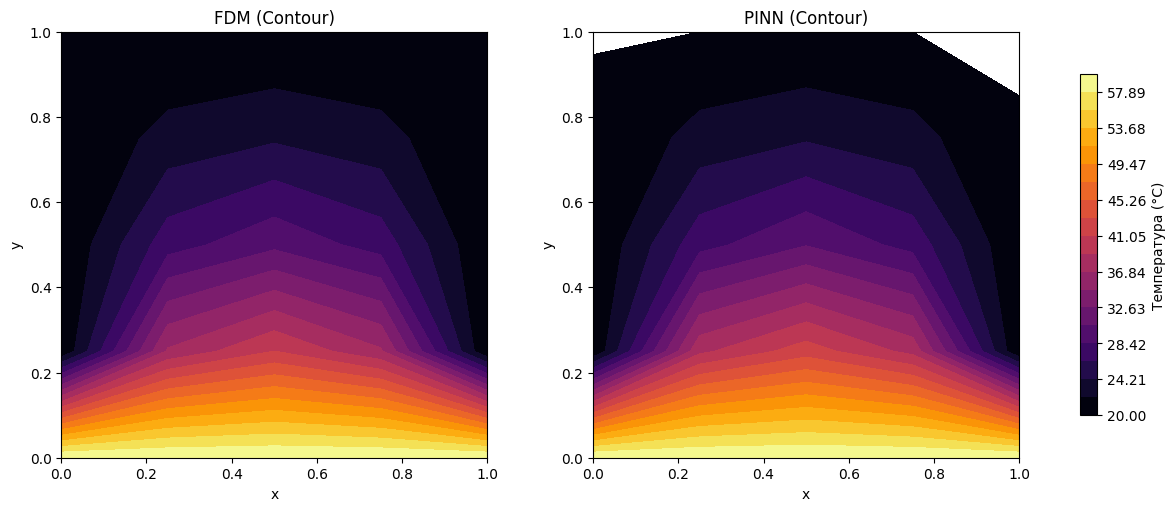

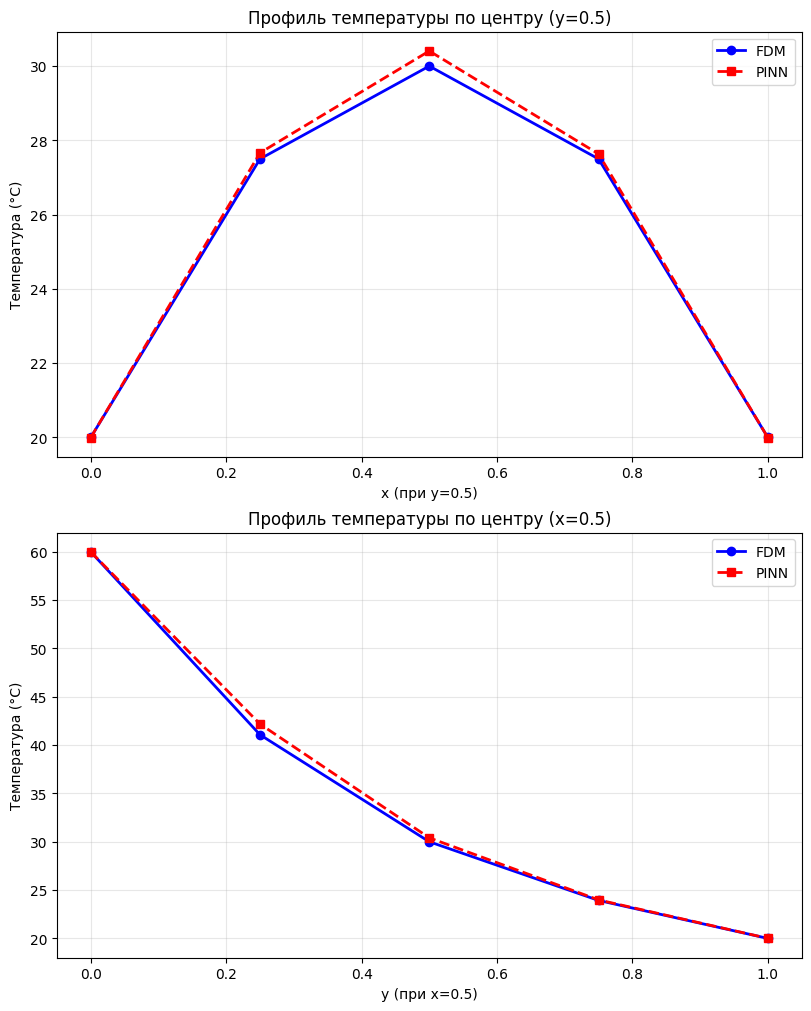

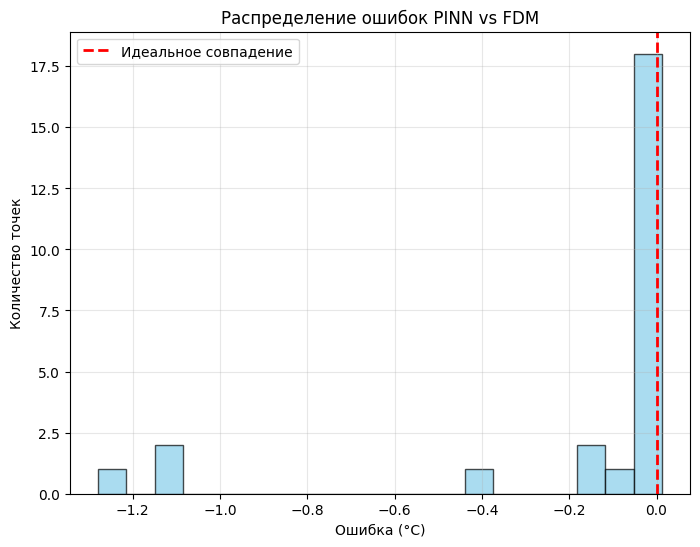

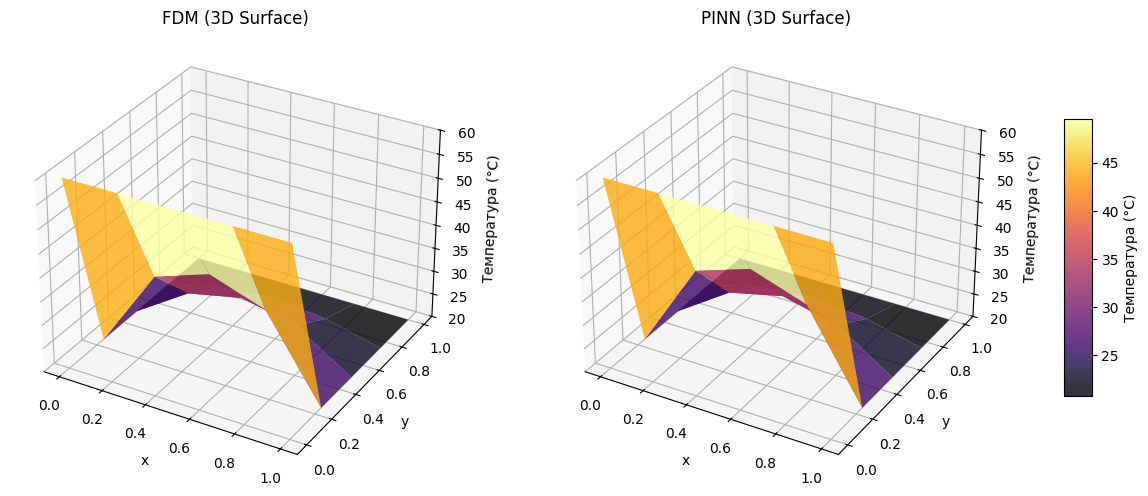


=== Статистика ошибок ===
Средняя абсолютная ошибка: 0.172157 °C
Максимальная абсолютная ошибка: 1.279167 °C
Стандартное отклонение ошибки: 0.377618 °C
RMSE: 0.413748 °C
Максимальная ошибка в точке: -1.279167 °C
Минимальная ошибка в точке: 0.000385 °C


In [7]:
# --- Дополнительные сравнения PINN vs FDM ---
print("\n=== Дополнительные визуализации сравнения ===")

# 1. Контурные графики (Contour plots)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

levels = np.linspace(T_cold, T_hot, 20)

cs1 = axes[0].contourf(X_mesh, Y_mesh, T_fdm, levels=levels, cmap='inferno')
axes[0].set_title('FDM (Contour)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_aspect('equal')

cs2 = axes[1].contourf(X_mesh, Y_mesh, T_pinn_flat, levels=levels, cmap='inferno')
axes[1].set_title('PINN (Contour)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_aspect('equal')

# Общий colorbar
cbar = fig.colorbar(cs1, ax=axes, shrink=0.8, orientation='vertical')
cbar.set_label('Температура (°C)')
plt.show()

# 2. Профили температуры вдоль центральных линий
fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

# Профиль по x при y=0.5 (центральная горизонтальная линия)
y_center = ny // 2
x_profile = X_mesh[y_center, :]
T_fdm_profile_x = T_fdm[y_center, :]
T_pinn_profile_x = T_pinn_flat[y_center, :]

axes[0].plot(x_profile, T_fdm_profile_x, 'b-o', label='FDM', linewidth=2, markersize=6)
axes[0].plot(x_profile, T_pinn_profile_x, 'r--s', label='PINN', linewidth=2, markersize=6)
axes[0].set_xlabel('x (при y=0.5)')
axes[0].set_ylabel('Температура (°C)')
axes[0].set_title('Профиль температуры по центру (y=0.5)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Профиль по y при x=0.5 (центральная вертикальная линия)
x_center = nx // 2
y_profile = Y_mesh[:, x_center]
T_fdm_profile_y = T_fdm[:, x_center]
T_pinn_profile_y = T_pinn_flat[:, x_center]

axes[1].plot(y_profile, T_fdm_profile_y, 'b-o', label='FDM', linewidth=2, markersize=6)
axes[1].plot(y_profile, T_pinn_profile_y, 'r--s', label='PINN', linewidth=2, markersize=6)
axes[1].set_xlabel('y (при x=0.5)')
axes[1].set_ylabel('Температура (°C)')
axes[1].set_title('Профиль температуры по центру (x=0.5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

# 3. Гистограмма распределения ошибок
error = T_fdm - T_pinn_flat
error_flat = error.ravel()

plt.figure(figsize=(8, 6))
plt.hist(error_flat, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Идеальное совпадение')
plt.xlabel('Ошибка (°C)')
plt.ylabel('Количество точек')
plt.title('Распределение ошибок PINN vs FDM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. 3D Surface plots
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# FDM 3D
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_mesh, Y_mesh, T_fdm, cmap='inferno', alpha=0.8)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Температура (°C)')
ax1.set_title('FDM (3D Surface)')
ax1.set_zlim(T_cold, T_hot)

# PINN 3D
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_mesh, Y_mesh, T_pinn_flat, cmap='inferno', alpha=0.8)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Температура (°C)')
ax2.set_title('PINN (3D Surface)')
ax2.set_zlim(T_cold, T_hot)

# Общий colorbar
cbar = fig.colorbar(surf1, ax=[ax1, ax2], shrink=0.6, aspect=10)
cbar.set_label('Температура (°C)')

plt.show()

# 5. Статистика ошибок
print("\n=== Статистика ошибок ===")
print(f"Средняя абсолютная ошибка: {np.mean(np.abs(error_flat)):.6f} °C")
print(f"Максимальная абсолютная ошибка: {np.max(np.abs(error_flat)):.6f} °C")
print(f"Стандартное отклонение ошибки: {np.std(error_flat):.6f} °C")
print(f"RMSE: {np.sqrt(np.mean(error_flat**2)):.6f} °C")
print(f"Максимальная ошибка в точке: {error_flat[np.argmax(np.abs(error_flat))]:.6f} °C")
print(f"Минимальная ошибка в точке: {error_flat[np.argmin(np.abs(error_flat))]:.6f} °C")